# **A Impressão Digital do Parlamentar: Uma Anatomia Multidimensional da Atuação Legislativa**

## Participantes: Adiel Emilson, Arthur Medeiros, Carlos Adauto, Davidys Pontes

---

## **Introdução**

A compreensão da dinâmica política brasileira exige uma visão que ultrapasse análises superficiais de discursos e filiações partidárias. Com o avanço das iniciativas de transparência e dados abertos, tornou-se possível investigar o comportamento e a trajetória dos representantes eleitos de forma empírica, quantitativa e rigorosa. É neste contexto que se desenvolve o projeto ``"A Impressão Digital do Parlamentar: Uma Anatomia Multidimensional da Atuação Legislativa"``, que propõe uma investigação estruturada sobre o perfil dos deputados federais.

Este relatório documenta os resultados obtidos através da aplicação de metodologias de introdução à ciência de dados para desvendar padrões na atuação parlamentar. Utilizando dados autênticos extraídos da API de Dados Abertos da Câmara dos Deputados, o estudo percorre o ciclo completo de análise de dados: desde o processo de requisição, limpeza e tratamento de valores ausentes, até a modelagem analítica avançada.

O objetivo central desta pesquisa é ir além da estatística descritiva básica, buscando correlações e perfis ocultos dentro do ecossistema legislativo. Com isso investigar as relações lineares entre variáveis contínuas (como idade na primeira legislatura, quantidade de eleições disputadas e idade na última legislatura) através de matrizes de correlação, identificando padrões históricos e comportamentais.

---

## **Descrição do Dataset**

| Coluna | Descrição |
|---|-------|
| `id` | Identificador único do parlamentar no sistema da Câmara dos Deputados. |
| ``nome_parlamentar``  | Nome público pelo qual o político atua e é conhecido na Câmara.  |
| `sigla_partido` | Histórico das siglas partidárias às quais o parlamentar esteve filiado ao longo das legislaturas registradas. | 
| `uri_partido` | Endereço de acesso (URL) aos dados do partido associado. |
| `sigla_uf `| Histórico das Unidades da Federação (estados) pelas quais o parlamentar foi eleito. |
| ``id_legislatura`` | Identificadores numéricos correspondentes aos períodos de legislatura (mandatos de 4 anos) em que o parlamentar esteve ativo. | 
| ``url_foto`` | Link de acesso direto para o retrato oficial do parlamentar. | 
| ``sexo`` | Sexo do parlamentar ( ``M`` para Masculino, ``F`` para Feminino). | 
| ``ultima_situação`` | Último status registado do mandato do parlamentar. |
| ``condicao_eleitoral`` | Condição na qual o parlamentar assumiu o mandato. |
| ``data_nascimento`` | Data de nascimento formatada no padrão ISO |
| ``falecido`` | Indicador binário sobre o óbito do parlamentar( ``0`` para vivo e ``1`` para falecido). |
| ``uf_nascimento`` | Sigla da Unidade da Federação de naturalidade do parlamentar. |
| ``escolaridade`` | Grau máximo de instrução formal declarado. |
| `quantidade_eleicoes` | Número total de eleições disputadas pelo parlamentar ao longo de sua carreira. |
| ``ultima_legislatura`` | Número da última legislatura (período legislativo) em que o parlamentar atuou ou foi eleito. |
| ``primeira_legislatura`` | Número da primeira legislatura em que o parlamentar iniciou sua atuação na Câmara. |
| ``idade_ultima_legislatura `` | dade aproximada do parlamentar no início ou durante a última legislatura. Pode ter valores nulos se o ano de nascimento for desconhecido. |
| ``idade_primeira_legislatura`` | dade aproximada do parlamentar no início ou durante a primeira legislatura. Pode ter valores nulos se o ano de nascimento for desconhecido. |

---

## **Importação de Frameworks**

In [1]:
%pip install pandas matplotlib seaborn requests scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import requests
from PIL import Image
from io import BytesIO

## **Exploração Inicial dos Dados**

In [3]:
pathDeputados = '../data/deputados.csv'
df = pd.read_csv(pathDeputados)

df.head()

,id,uri,nomeParlamentar,siglaPartido,uriPartido,siglaUf,idLegislatura,urlFoto,email,sexo,ultimaSituacao,condicaoEleitoral,nomeEleitoral,nomeCivil,dataNascimento,falecido,udNascimento,escolaridade
0,1500,https://dadosabertos.camara.leg.br/api/v2/depu...,MÁRIO LIMA,"['PMDB', 'PSB*']",https://dadosabertos.camara.leg.br/api/v2/part...,['BA'],"[48, 42, 47]",https://www.camara.leg.br/internet/deputado/ba...,NaN,M,Vacância,Titular,MÁRIO LIMA,MÁRIO SOARES LIMA,1935-02-19,0,BA,Secundário
1,1501,https://dadosabertos.camara.leg.br/api/v2/depu...,MAURÍCIO FRUET,"['PMDB', 'MDB*']",https://dadosabertos.camara.leg.br/api/v2/part...,['PR'],"[48, 46, 47]",https://www.camara.leg.br/internet/deputado/ba...,NaN,M,Vacância,Titular,MAURÍCIO FRUET,Maurício Roslindo Fruet,1939-08-12,0,PR,Superior
2,1502,https://dadosabertos.camara.leg.br/api/v2/depu...,OSWALDO ALMEIDA,['PL*'],https://dadosabertos.camara.leg.br/api/v2/part...,['RJ'],[48],https://www.camara.leg.br/internet/deputado/ba...,NaN,M,NaN,Titular,OSWALDO ALMEIDA,Oswaldo Barreto de Almeida,1933-10-22,0,RJ,Superior
3,1503,https://dadosabertos.camara.leg.br/api/v2/depu...,OSWALDO LIMA FILHO,"['PMDB', 'PSP', 'MDB*', 'PTB']",https://dadosabertos.camara.leg.br/api/v2/part...,['PE'],"[40, 41, 42, 43, 47, 48]",https://www.camara.leg.br/internet/deputado/ba...,NaN,M,Vacância,Efetivado,OSWALDO LIMA FILHO,Oswaldo Cavalcanti da Costa Lima Filho,1921-04-26,0,PE,Superior
4,1504,https://dadosabertos.camara.leg.br/api/v2/depu...,TITO COSTA,['PMDB'],https://dadosabertos.camara.leg.br/api/v2/part...,['SP'],[48],https://www.camara.leg.br/internet/deputado/ba...,NaN,M,NaN,Suplente,TITO COSTA,Antonio Tito Costa,1922-12-31,0,SP,Superior


##### Verificando se todas colunas estão com seus dados com os valores corretos 

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 5190 non-null   int64
 1   uri                5190 non-null   str  
 2   nomeParlamentar    5190 non-null   str  
 3   siglaPartido       5190 non-null   str  
 4   uriPartido         5187 non-null   str  
 5   siglaUf            5190 non-null   str  
 6   idLegislatura      5190 non-null   str  
 7   urlFoto            5190 non-null   str  
 8   email              513 non-null    str  
 9   sexo               5190 non-null   str  
 10  ultimaSituacao     3832 non-null   str  
 11  condicaoEleitoral  5145 non-null   str  
 12  nomeEleitoral      5190 non-null   str  
 13  nomeCivil          5190 non-null   str  
 14  dataNascimento     5155 non-null   str  
 15  falecido           5190 non-null   int64
 16  udNascimento       5106 non-null   str  
 17  escolaridade       4755 n

##### Verificando quantos nulos cada coluna possuem, para identificar quais serão necessario manipular e limpar

In [5]:
df.isnull().sum()

id                      0
uri                     0
nomeParlamentar         0
siglaPartido            0
uriPartido              3
siglaUf                 0
idLegislatura           0
urlFoto                 0
email                4677
sexo                    0
ultimaSituacao       1358
condicaoEleitoral      45
nomeEleitoral           0
nomeCivil               0
dataNascimento         35
falecido                0
udNascimento           84
escolaridade          435
dtype: int64

In [6]:
df.describe()

,id,falecido
count,5190.000000,5190.000000
mean,123536.173218,0.007514
std,49973.629149,0.086368
min,1500.000000,0.000000
25%,74533.250000,0.000000
50%,131278.500000,0.000000
75%,139364.750000,0.000000
max,235088.000000,1.000000


### **Limpeza dos dados**

In [7]:
df.columns

Index(['id', 'uri', 'nomeParlamentar', 'siglaPartido', 'uriPartido', 'siglaUf',
       'idLegislatura', 'urlFoto', 'email', 'sexo', 'ultimaSituacao',
       'condicaoEleitoral', 'nomeEleitoral', 'nomeCivil', 'dataNascimento',
       'falecido', 'udNascimento', 'escolaridade'],
      dtype='str')

#### **Decisões**

 - Remoção da coluna emails pois ela não possuia nenhum valor não nulo
 - Remoção da coluna 'nomeCivil' por conter os mesmo valores que a coluna 'nomeParlamentar'
 - Remoção da coluna 'nomeEleitoral' por conter os mesmo valores que a coluna 'nomeParlamentar'
 - Separar o ano de nascimento da data de nascimento para melhor visibiladade
 - Remoção da coluna uri pois não tinha utilidade

In [8]:
df.drop(columns='email', inplace=True)

In [9]:
df.drop(columns='nomeCivil', inplace=True)

In [10]:
df.drop(columns='nomeEleitoral', inplace=True)

In [11]:
df['ano_nascimento'] = pd.to_datetime(df['dataNascimento'], errors='coerce').dt.year.astype('Int64')

In [12]:
df.drop(columns='dataNascimento', inplace=True)

In [13]:
df.drop(columns='uri', inplace=True)

### **Preechimento de valores nulos**

In [14]:
df['ultimaSituacao'] = df['ultimaSituacao'].fillna("SEM_INFORMACAO")

In [15]:
df['condicaoEleitoral'] = df['condicaoEleitoral'].fillna("SEM_INFORMACAO")

In [16]:
df['udNascimento'] = df['udNascimento'].fillna("SEM_INFORMACAO")

In [17]:
df['escolaridade'] = df['escolaridade'].fillna("SEM_INFORMACAO")

### **Padronização de colunas**

#### Padronizando as colunas para caixa alta para facilidade para tratar os dados


In [ ]:
df['sexo'] = df['sexo'].str.upper() # Converte o conteúdo da coluna 'sexo' para maiúsculas

In [ ]:
df['nomeParlamentar'] = df['nomeParlamentar'].str.upper() # Converte o conteúdo da coluna 'nomeParlamentar' para maiúsculas para garantir a consistência dos dados, facilitando a análise e visualização dos nomes dos parlamentares. Isso é especialmente útil para evitar problemas de comparação de strings devido a diferenças de capitalização.

In [ ]:
df['ultimaSituacao'] = df['ultimaSituacao'].str.upper() # Converte o conteúdo da coluna 'ultimaSituacao' para maiúsculas para garantir a consistência dos dados, facilitando a análise e visualização das situações dos parlamentares. Isso é especialmente útil para evitar problemas de comparação de strings devido a diferenças de capitalização.

In [ ]:
df['condicaoEleitoral'] = df['condicaoEleitoral'].str.upper() # Converte o conteúdo da coluna 'condicaoEleitoral' para maiúsculas para garantir a consistência dos dados, facilitando a análise e visualização das condições eleitorais dos parlamentares. Isso é especialmente útil para evitar problemas de comparação de strings devido a diferenças de capitalização.

In [ ]:
df['escolaridade'] = df['escolaridade'].str.upper() # Converte o conteúdo da coluna 'escolaridade' para maiúsculas para garantir a consistência dos dados, facilitando a análise e visualização dos níveis de escolaridade dos parlamentares. Isso é especialmente útil para evitar problemas de comparação de strings devido a diferenças de capitalização.

In [23]:
df.head()

,id,nomeParlamentar,siglaPartido,uriPartido,siglaUf,idLegislatura,urlFoto,sexo,ultimaSituacao,condicaoEleitoral,falecido,udNascimento,escolaridade,ano_nascimento
0,1500,MÁRIO LIMA,"['PMDB', 'PSB*']",https://dadosabertos.camara.leg.br/api/v2/part...,['BA'],"[48, 42, 47]",https://www.camara.leg.br/internet/deputado/ba...,M,VACÂNCIA,TITULAR,0,BA,SECUNDÁRIO,1935
1,1501,MAURÍCIO FRUET,"['PMDB', 'MDB*']",https://dadosabertos.camara.leg.br/api/v2/part...,['PR'],"[48, 46, 47]",https://www.camara.leg.br/internet/deputado/ba...,M,VACÂNCIA,TITULAR,0,PR,SUPERIOR,1939
2,1502,OSWALDO ALMEIDA,['PL*'],https://dadosabertos.camara.leg.br/api/v2/part...,['RJ'],[48],https://www.camara.leg.br/internet/deputado/ba...,M,SEM_INFORMACAO,TITULAR,0,RJ,SUPERIOR,1933
3,1503,OSWALDO LIMA FILHO,"['PMDB', 'PSP', 'MDB*', 'PTB']",https://dadosabertos.camara.leg.br/api/v2/part...,['PE'],"[40, 41, 42, 43, 47, 48]",https://www.camara.leg.br/internet/deputado/ba...,M,VACÂNCIA,EFETIVADO,0,PE,SUPERIOR,1921
4,1504,TITO COSTA,['PMDB'],https://dadosabertos.camara.leg.br/api/v2/part...,['SP'],[48],https://www.camara.leg.br/internet/deputado/ba...,M,SEM_INFORMACAO,SUPLENTE,0,SP,SUPERIOR,1922


### Verificando a condição eleitoral dos deputados

In [24]:
df.condicaoEleitoral.value_counts()    

condicaoEleitoral
TITULAR           3825
SUPLENTE          1105
EFETIVADO          207
SEM_INFORMACAO      45
NÃO ELEITO           6
ELEITO               2
Name: count, dtype: int64

In [25]:
df.isnull().sum()

id                    0
nomeParlamentar       0
siglaPartido          0
uriPartido            3
siglaUf               0
idLegislatura         0
urlFoto               0
sexo                  0
ultimaSituacao        0
condicaoEleitoral     0
falecido              0
udNascimento          0
escolaridade          0
ano_nascimento       35
dtype: int64

##### Verificando se possue valores repetidos

In [26]:
df.nomeParlamentar.value_counts()

nomeParlamentar
ROCHA LOURES        3
WILSON CUNHA        3
CARLOS ALBERTO      3
CARVALHO NETO       3
SÉRGIO CARVALHO     2
                   ..
ELMANO FÉRRER       1
VANDERLAN ALVES     1
HELOÍSA HELENA      1
CRISTIANO FURLAN    1
RIBEIRO NETO        1
Name: count, Length: 5099, dtype: int64

##### Colocando nome das colunas de camelCase para snake_case

In [27]:
df.rename(columns={'nomeParlamentar': 'nome_parlamentar', 'uriPartido': 'uri_partido', 'dataNascimento': 'data_nascimento', 'siglaPartido': 'sigla_partido', 'siglaUf': 'sigla_uf', "udNascimento": "uf_nascimento", "idLegislatura": "id_legislatura", "urlFoto": "url_foto", "ultimaSituacao": "ultima_situacao", 'condicaoEleitoral': 'condicao_eleitoral'}, inplace=True)

### **Análise Exploratória dos Dados - EDA**

In [28]:
df.head()

,id,nome_parlamentar,sigla_partido,uri_partido,sigla_uf,id_legislatura,url_foto,sexo,ultima_situacao,condicao_eleitoral,falecido,uf_nascimento,escolaridade,ano_nascimento
0,1500,MÁRIO LIMA,"['PMDB', 'PSB*']",https://dadosabertos.camara.leg.br/api/v2/part...,['BA'],"[48, 42, 47]",https://www.camara.leg.br/internet/deputado/ba...,M,VACÂNCIA,TITULAR,0,BA,SECUNDÁRIO,1935
1,1501,MAURÍCIO FRUET,"['PMDB', 'MDB*']",https://dadosabertos.camara.leg.br/api/v2/part...,['PR'],"[48, 46, 47]",https://www.camara.leg.br/internet/deputado/ba...,M,VACÂNCIA,TITULAR,0,PR,SUPERIOR,1939
2,1502,OSWALDO ALMEIDA,['PL*'],https://dadosabertos.camara.leg.br/api/v2/part...,['RJ'],[48],https://www.camara.leg.br/internet/deputado/ba...,M,SEM_INFORMACAO,TITULAR,0,RJ,SUPERIOR,1933
3,1503,OSWALDO LIMA FILHO,"['PMDB', 'PSP', 'MDB*', 'PTB']",https://dadosabertos.camara.leg.br/api/v2/part...,['PE'],"[40, 41, 42, 43, 47, 48]",https://www.camara.leg.br/internet/deputado/ba...,M,VACÂNCIA,EFETIVADO,0,PE,SUPERIOR,1921
4,1504,TITO COSTA,['PMDB'],https://dadosabertos.camara.leg.br/api/v2/part...,['SP'],[48],https://www.camara.leg.br/internet/deputado/ba...,M,SEM_INFORMACAO,SUPLENTE,0,SP,SUPERIOR,1922


#### Criamos uma função tamanho para criar a coluna "quantidade_eleicoes", que se baseia no tamanho da lista do 'id_legislatura'

In [29]:
def tamanho(x):
    return len(str(x).split(','))

In [30]:
df['quantidade_eleicoes'] = df['id_legislatura'].apply(tamanho)

Baseado nos ids, conseguimos determinar que o ano de início de cada legislatura é determinado por

$$4\cdot id+1794$$

e com isso futuramente ter a informaçào dos anos dos mandatos exatos

#### Extração das legislaturas (primeira e última)

A coluna `id_legislatura` contém uma lista de períodos legislativos de cada parlamentar. Para extrair informações temporais significativas, desenvolvemos uma lógica que:

1. **Identifica a legislatura mais recente**: extrai o ID máximo da lista e aplica a fórmula ($4 \cdot id + 1794$) para obter o ano da última legislatura ativa
2. **Identifica a legislatura mais antiga**: extrai o ID mínimo da lista e aplica a mesma fórmula para obter o ano da primeira legislatura

Esse processo permite rastrear toda a trajetória legislativa de cada deputado, desde sua estreia até sua última atividade.

In [31]:
ultima_legislatura = df['id_legislatura'].apply(
    lambda x: max(
        map(int, str(x).replace('[', '').replace(']', '').split(','))
    )
)

df['ultima_legislatura'] = ultima_legislatura * 4 + 1794

In [32]:
primeira_legislatura = df['id_legislatura'].apply(
    lambda x: min(
        map(int, str(x).replace('[', '').replace(']', '').split(','))
    )
)

df['primeira_legislatura'] = primeira_legislatura * 4 + 1794

#### Cálculo das idades parlamentares

Com base no ano de nascimento dos deputados e nos anos das legislaturas, calculamos as idades de entrada e última atividade:

- **Idade na primeira legislatura**: idade do parlamentar ao ingressar no parlamento
- **Idade na última legislatura**: idade do parlamentar em sua atividade parlamentar mais recente

Essas variáveis são essenciais para análises de perfil e trajetória política dos representantes.

In [33]:
df['idade_ultima_legislatura'] = df['ultima_legislatura'] - df['ano_nascimento']
df['idade_primeira_legislatura'] = df['primeira_legislatura'] - df['ano_nascimento']

In [34]:
df.head()

,id,nome_parlamentar,sigla_partido,uri_partido,sigla_uf,id_legislatura,url_foto,sexo,ultima_situacao,condicao_eleitoral,falecido,uf_nascimento,escolaridade,ano_nascimento,quantidade_eleicoes,ultima_legislatura,primeira_legislatura,idade_ultima_legislatura,idade_primeira_legislatura
0,1500,MÁRIO LIMA,"['PMDB', 'PSB*']",https://dadosabertos.camara.leg.br/api/v2/part...,['BA'],"[48, 42, 47]",https://www.camara.leg.br/internet/deputado/ba...,M,VACÂNCIA,TITULAR,0,BA,SECUNDÁRIO,1935,3,1986,1962,51,27
1,1501,MAURÍCIO FRUET,"['PMDB', 'MDB*']",https://dadosabertos.camara.leg.br/api/v2/part...,['PR'],"[48, 46, 47]",https://www.camara.leg.br/internet/deputado/ba...,M,VACÂNCIA,TITULAR,0,PR,SUPERIOR,1939,3,1986,1978,47,39
2,1502,OSWALDO ALMEIDA,['PL*'],https://dadosabertos.camara.leg.br/api/v2/part...,['RJ'],[48],https://www.camara.leg.br/internet/deputado/ba...,M,SEM_INFORMACAO,TITULAR,0,RJ,SUPERIOR,1933,1,1986,1986,53,53
3,1503,OSWALDO LIMA FILHO,"['PMDB', 'PSP', 'MDB*', 'PTB']",https://dadosabertos.camara.leg.br/api/v2/part...,['PE'],"[40, 41, 42, 43, 47, 48]",https://www.camara.leg.br/internet/deputado/ba...,M,VACÂNCIA,EFETIVADO,0,PE,SUPERIOR,1921,6,1986,1954,65,33
4,1504,TITO COSTA,['PMDB'],https://dadosabertos.camara.leg.br/api/v2/part...,['SP'],[48],https://www.camara.leg.br/internet/deputado/ba...,M,SEM_INFORMACAO,SUPLENTE,0,SP,SUPERIOR,1922,1,1986,1986,64,64


 #### Transformando o df com as novas colunas em csv

In [35]:
df.to_csv('../data/deputados_tratados.csv')

## Início da análise exploratória
De início, iremos analiser a distribuição geral dos nossos dados.

C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\838825010.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.countplot(df, x='sexo', palette='tab10')


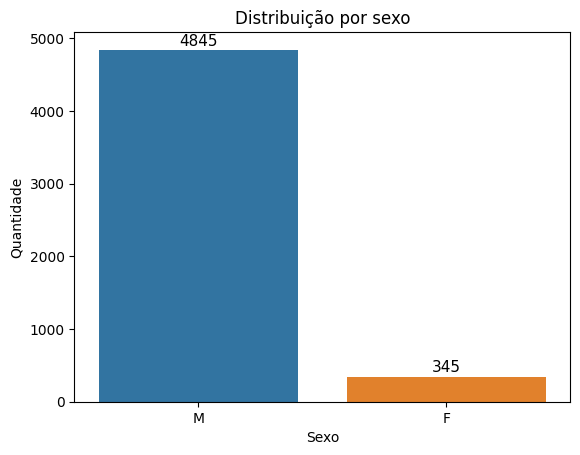

In [36]:
fig = sns.countplot(df, x='sexo', palette='tab10')
fig.set(title='Distribuição por sexo', xlabel="Sexo",ylabel='Quantidade');

for c in fig.containers:
    fig.bar_label(c, fontsize=11, padding=1)

C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\768735534.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.countplot(df, x='falecido', palette='tab10')


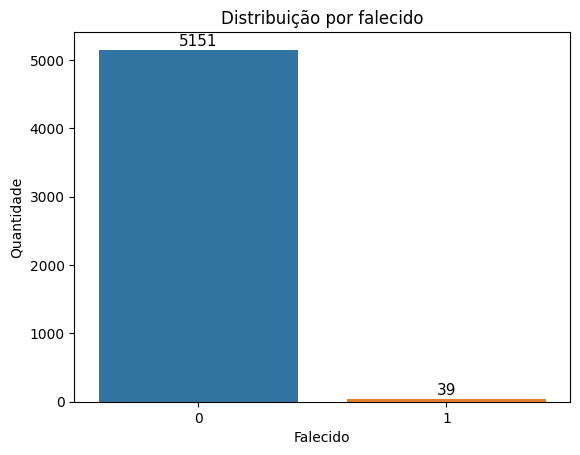

In [37]:
fig = sns.countplot(df, x='falecido', palette='tab10')
fig.set(title='Distribuição por falecido', xlabel="Falecido",ylabel='Quantidade');


for c in fig.containers:
    fig.bar_label(c, fontsize=11, padding=1)

C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\4186765174.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  fig = sns.histplot(df, x='idade_ultima_legislatura', bins=20, kde=True, palette='tab10')


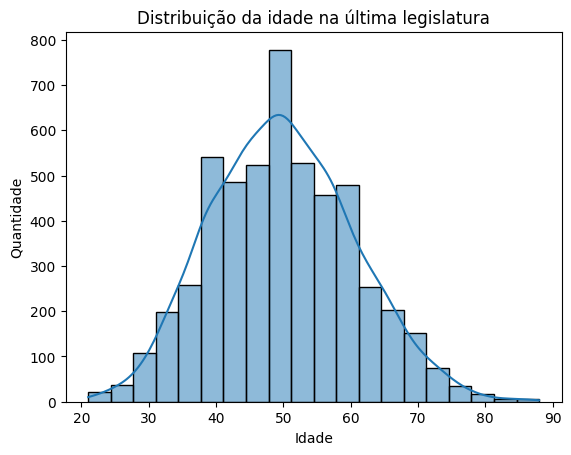

In [38]:
fig = sns.histplot(df, x='idade_ultima_legislatura', bins=20, kde=True, palette='tab10')
fig.set(title='Distribuição da idade na última legislatura', xlabel="Idade",ylabel='Quantidade');

### Analisando quais são os deputados mais velhos nas últimas legislaturas

Para criar este gráfico, utilizamos a biblioteca `requests` para baixar as fotos dos deputados a partir das URLs armazenadas na coluna `url_foto`. Com base na coluna `idade_ultima_legislatura`, selecionamos os deputados mais velhos ao ingressarem no cargo. Como apenas dois deputados tinham 88 anos, incluímos o (88 - 1) para completar o gráfico, como possuia apenas um deputado com 87 anos ficamos com um top 3 definido.

Para definir o estado do deputado exibido no título, organizamos a lista de siglas dos estados onde atuaram e selecionamos o primeiro. Isso é feito com a linha de código que limpa a string da coluna `sigla_uf` (removendo colchetes e aspas) e extrai o primeiro elemento após dividir por vírgula.

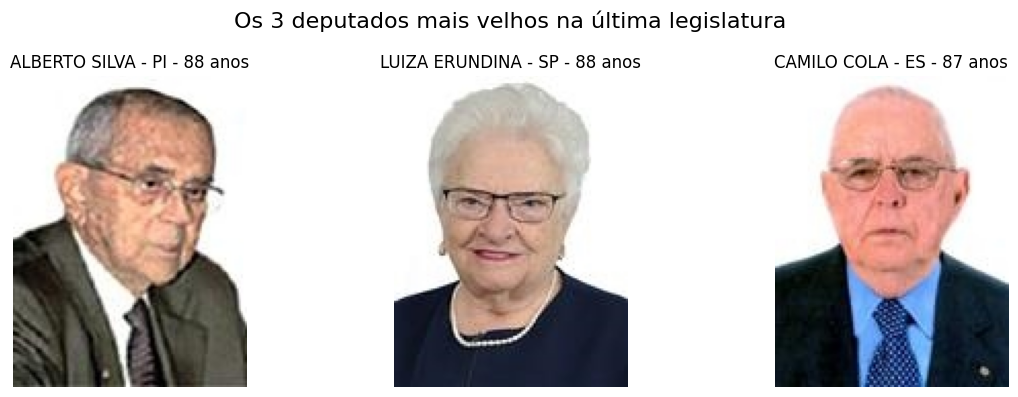

In [39]:
mais_velho = df[df['idade_ultima_legislatura'] >= df['idade_ultima_legislatura'].max()-1]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

for i, (_, row) in enumerate(mais_velho.iterrows()):
    nome = row['nome_parlamentar']
    url = row['url_foto']
    estado = row['sigla_uf'].replace("[", "").replace("]", "").replace("'", "").split(",")[0].strip()
    idade_ultima_legislatura = row['idade_ultima_legislatura']

    response = requests.get(url)
    img = Image.open(BytesIO(response.content))

    ax[i].imshow(img)
    ax[i].set_title(f"{nome} - {estado} - {idade_ultima_legislatura} anos")
    ax[i].axis('off')

plt.suptitle("Os 3 deputados mais velhos na última legislatura", fontsize=16)
plt.tight_layout()
plt.show()

C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\933229638.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  fig = sns.histplot(df, x='idade_primeira_legislatura', bins=20, kde=True, palette='tab10')


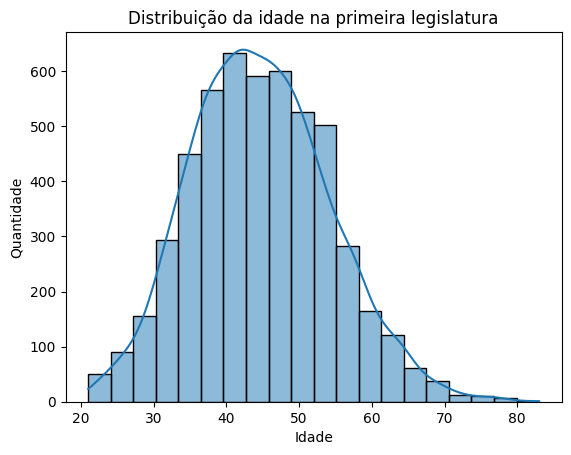

In [40]:
fig = sns.histplot(df, x='idade_primeira_legislatura', bins=20, kde=True, palette='tab10')
fig.set(title='Distribuição da idade na primeira legislatura', xlabel="Idade",ylabel='Quantidade');

### Analisando os deputados mais novos a assumirem o cargo

#### Nesta etapa, repetimos o processo da análise anterior, mas agora focando nos deputados mais jovens ao ingressarem no cargo. Identificamos que há 8 deputados que assumiram o mandato com a idade mínima permitida pela legislação. Após uma pesquisa simples, descobrimos que Amom Mandel foi o deputado mais votado do Amazonas (AM), Hugo Motta é o atual presidente da Câmara dos Deputados, e Patrick Dornelles foi o primeiro deputado com deficiência rara a ingressar no cargo e que por dificuldades de saúde se retirou do cargo.

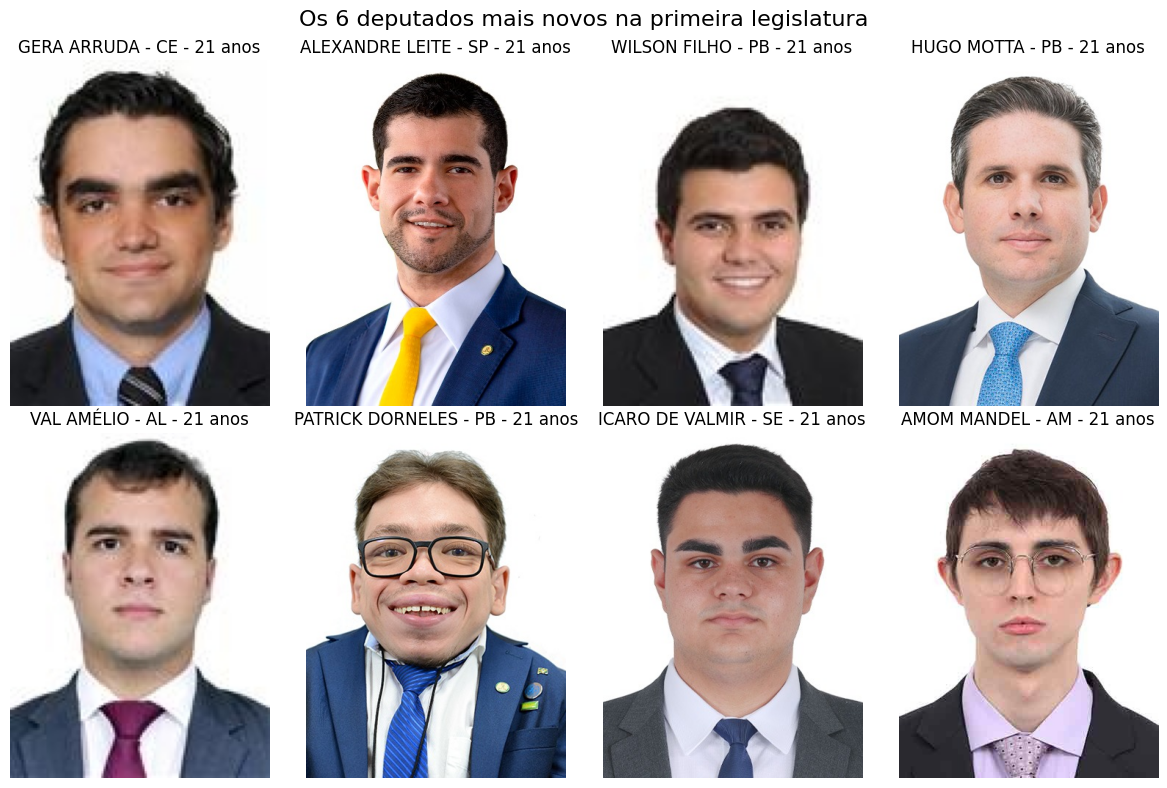

In [41]:
mais_novos = df[df['idade_primeira_legislatura'] == df['idade_primeira_legislatura'].min()]
mais_novos

fig, ax = plt.subplots(2, 4, figsize=(12, 8))

for i, (_, row) in enumerate(mais_novos.iterrows()):
    linha = i // 4
    nome = row['nome_parlamentar']
    url = row['url_foto']
    estado = row['sigla_uf'].replace("[", "").replace("]", "").replace("'", "").split(",")[0].strip()
    idade_primeira_legislatura = row['idade_primeira_legislatura']

    response = requests.get(url)
    img = Image.open(BytesIO(response.content))

    ax[linha, i % 4].imshow(img)
    ax[linha, i % 4].set_title(f"{nome} - {estado} - {idade_primeira_legislatura} anos")
    ax[linha, i % 4].axis('off')

plt.suptitle("Os 6 deputados mais novos na primeira legislatura", fontsize=16)
plt.tight_layout()
plt.show()


### Analisando os deputados mais velhos a ingressarem no cargo 

##### Repetindo a análise apresentada anteriormente, neste gráfico focamos nos deputados mais velhos ao ingressarem no cargo. Com isso, conseguimos identificar alguns nomes interessantes, como Camilo Cola, que é veterano da Segunda Guerra Mundial, e Elmano Férrer, que foi prefeito de Teresina e senador do Piauí.

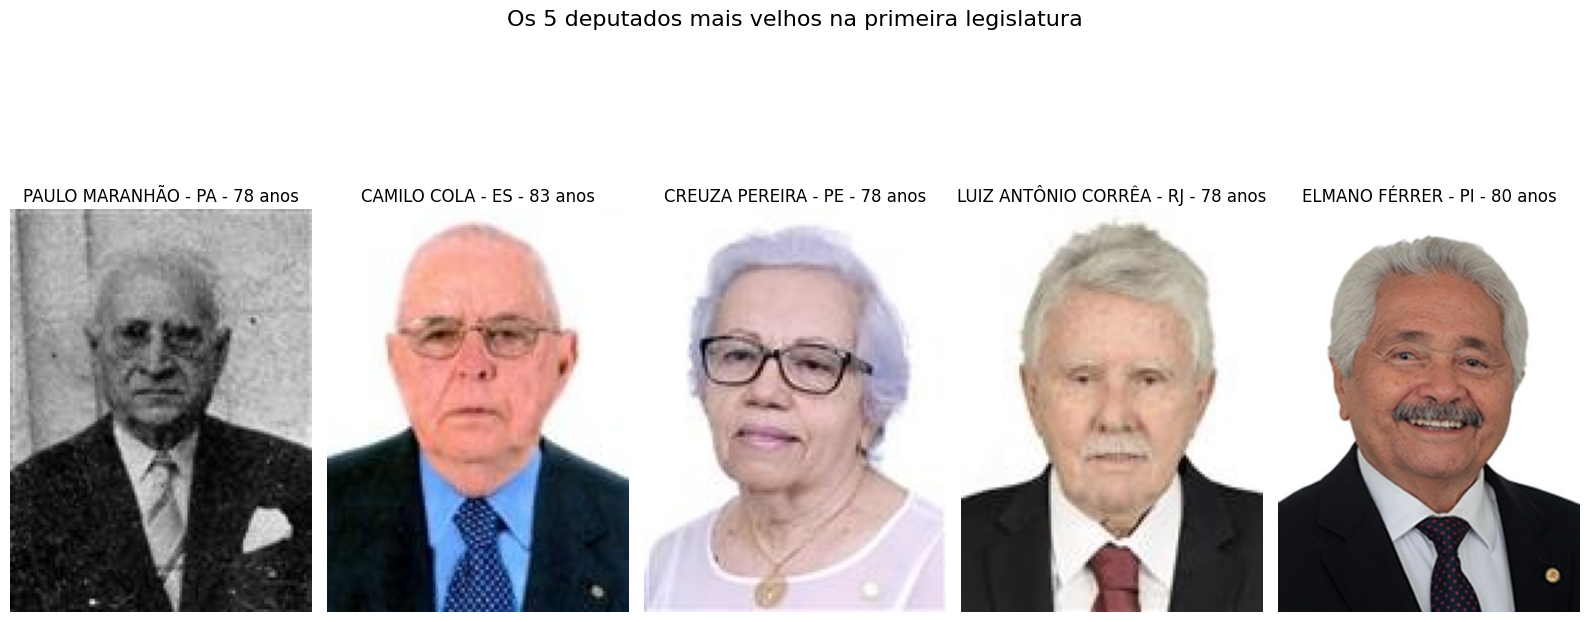

In [42]:
mais_velhos = df[df['idade_primeira_legislatura'] >= df['idade_primeira_legislatura'].max()-5]

fig, ax = plt.subplots(1, 5, figsize=(16, 8))

for i, (_, row) in enumerate(mais_velhos.iterrows()):
    nome = row['nome_parlamentar']
    url = row['url_foto']
    estado = row['sigla_uf'].replace("[", "").replace("]", "").replace("'", "").split(",")[0].strip()
    idade_primeira_legislatura = row['idade_primeira_legislatura']

    response = requests.get(url)
    img = Image.open(BytesIO(response.content))

    ax[i].imshow(img)
    ax[i].set_title(f"{nome} - {estado} - {idade_primeira_legislatura} anos")
    ax[i].axis('off')

plt.suptitle("Os 5 deputados mais velhos na primeira legislatura", fontsize=16)
plt.tight_layout()
plt.show()


#### Distribuição por Última Situação

Neste gráfico focamos na distribuição dos deputados federais com base na última situação registrada de seu mandato, excluindo os casos sem informação. Observamos que a maioria dos deputados teve como última situação "VACÂNCIA", o que pode refletir interrupções ou mudanças em suas carreiras políticas.. Esse gráfico ajuda a entender os padrões de término de mandato e a estabilidade na representação parlamentar.

C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\2600840177.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.countplot(df[df['ultima_situacao'] != "SEM_INFORMACAO"], x='ultima_situacao', palette='tab10')


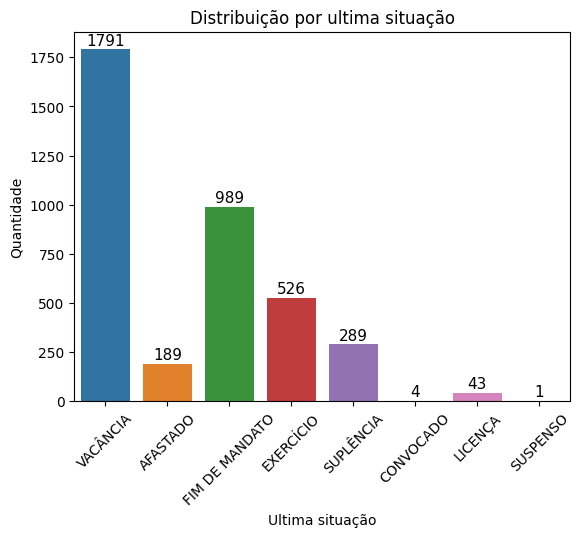

In [43]:
fig = sns.countplot(df[df['ultima_situacao'] != "SEM_INFORMACAO"], x='ultima_situacao', palette='tab10')
fig.set(title="Distribuição por ultima situação", xlabel="Ultima situação", ylabel="Quantidade")
fig.tick_params(axis='x', labelrotation=45)

for c in fig.containers:
    fig.bar_label(c, fontsize=11, padding=1)

### Analisando os partidos com mais deputados

##### Para criar este gráfico, utilizamos a coluna `sigla_partido`, que contém as siglas dos partidos pelos quais os deputados foram eleitos. Como essa coluna pode conter múltiplas siglas (caso o deputado tenha sido eleito por mais de um partido), realizamos um processo de "explosão" da coluna para transformar cada sigla em uma linha separada. Em seguida, contamos a frequência de cada sigla e selecionamos o top 15 para exibir no gráfico. O resultado mostra que partidos mais antigos e tradicionais, como o PMDB (atual MDB) e o PSD, possuem uma presença significativa entre os deputados federais, refletindo sua influência histórica na política brasileira. Além disso, partidos como o PSD e o PTB também se destacam, indicando uma diversidade de representatividade partidária no Congresso Nacional. Já os partidos mais recentes, como o PL, apresentam uma presença menor, o que pode ser atribuído à sua trajetória mais curta na política brasileira.

C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\2045178708.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.countplot(x=partidos_long[partidos_long.isin(top15)], order=top15, palette='tab10')


C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\2045178708.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.countplot(x=partidos_long[partidos_long.isin(top15)], order=top15, palette='tab10')


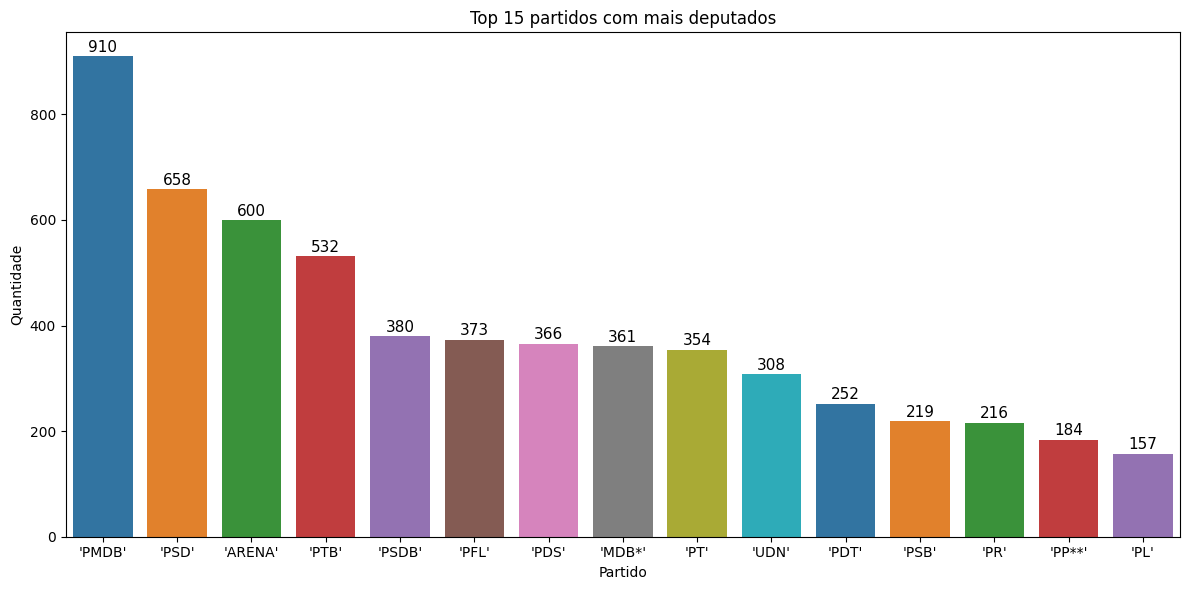

In [68]:
partidos_long = (
df["sigla_partido"]
.str.replace("[", "", regex=False)
.str.replace("]", "", regex=False)
.str.replace('"', "", regex=False)
.str.split(",")
.explode()
.str.strip()
)

plt.figure(figsize=(12, 6))
top15 = partidos_long.value_counts().head(15).index
fig = sns.countplot(x=partidos_long[partidos_long.isin(top15)], order=top15, palette='tab10')
fig.set(title="Top 15 partidos com mais deputados", xlabel="Partido", ylabel="Quantidade");
plt.tight_layout()

for c in fig.containers:
    fig.bar_label(c, fontsize=11, padding=1)


### Analisando a distribuição de deputados por Estado

##### Para criar este gráfico, utilizamos a coluna `sigla_uf`, que contém as siglas dos estados pelos quais os deputados foram eleitos. Como essa coluna pode conter múltiplas siglas (caso o deputado tenha sido eleito por mais de um estado), realizamos um processo de "explosão" da coluna para transformar cada sigla em uma linha separada. Em seguida, contamos a frequência de cada sigla e selecionamos as 27 mais comuns para exibir no gráfico. O resultado mostra quais estados têm a maior representação de deputados federais, destacando os centros políticos mais influentes do país.

C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\529913947.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.countplot(x=estados_long[estados_long.isin(ordem_estados)], order=ordem_estados, palette='tab10')


C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\529913947.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.countplot(x=estados_long[estados_long.isin(ordem_estados)], order=ordem_estados, palette='tab10')


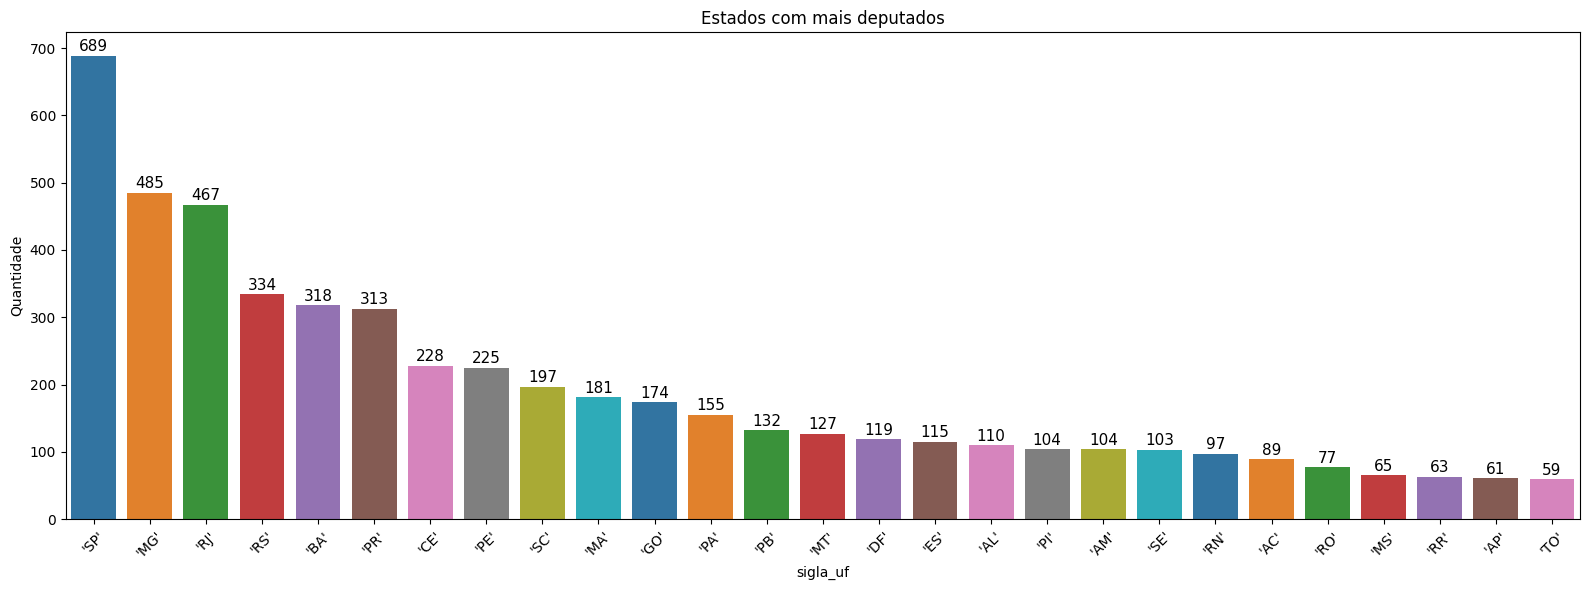

In [65]:
estados_long = (
df["sigla_uf"]
.str.replace("[", "", regex=False)
.str.replace("]", "", regex=False)
.str.replace('"', "", regex=False)
.str.split(",")
.explode()
.str.strip()
)


ordem_estados = estados_long.value_counts().head(27).index
plt.figure(figsize=(16, 6))
fig = sns.countplot(x=estados_long[estados_long.isin(ordem_estados)], order=ordem_estados, palette='tab10')
fig.set(title="Estados com mais deputados", xlabel="sigla_uf", ylabel="Quantidade");
plt.xticks(rotation=45)
plt.tight_layout()

for c in fig.containers:
    fig.bar_label(c, fontsize=11, padding=1)

### Analisando a distribuição de deputados por escolaridade

##### Para criar este gráfico focamos na coluna ``escolaridade`` para analisar a distribuição dos deputados federais com base em seu grau máximo de instrução formal declarado. Observamos que a maioria dos deputados possui ensino superior completo, seguido por aqueles com ensino superior incompleto,ensino médio completo e pós-graduação. Essa análise revela o perfil educacional predominante entre os representantes eleitos, indicando uma tendência de maior escolaridade entre os parlamentares federais.

C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\276667763.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.countplot(df, y='escolaridade', palette='tab10')


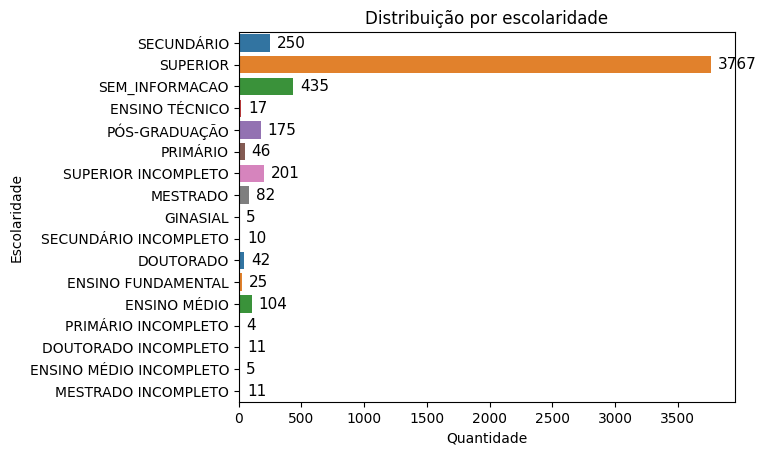

In [46]:
fig = sns.countplot(df, y='escolaridade', palette='tab10')
fig.set(title="Distribuição por escolaridade", xlabel="Quantidade", ylabel="Escolaridade")

for c in fig.containers:
    fig.bar_label(c, fontsize=11, padding=5)

#### Vendo que a discrepância dos deputados que possuem ensino superior completo é muito grande, decidimos criar um novo gráfico para analisar melhor a destribuição dos deputados por escolaridade. O resultado mostra que a maioria dos deputados possui ensino superior incompleto, seguido por aqueles com ensino médio completo e pós-graduação. Essa análise revela o perfil educacional predominante entre os representantes eleitos, indicando uma tendência de maior escolaridade entre os parlamentares federais.

C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\1877124401.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.countplot(df[df['escolaridade'] != 'SUPERIOR'], y='escolaridade', palette='tab10')


C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\1877124401.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.countplot(df[df['escolaridade'] != 'SUPERIOR'], y='escolaridade', palette='tab10')


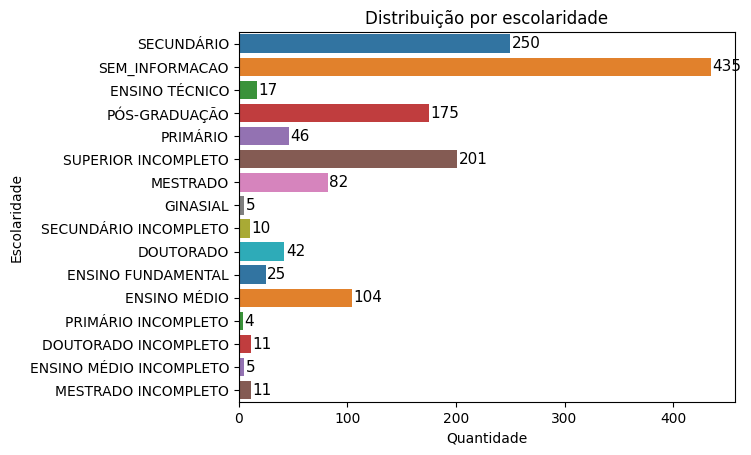

<Figure size 1600x600 with 0 Axes>

In [72]:
fig = sns.countplot(df[df['escolaridade'] != 'SUPERIOR'], y='escolaridade', palette='tab10')
fig.set(title="Distribuição por escolaridade", xlabel="Quantidade", ylabel="Escolaridade")
plt.figure(figsize=(16, 6))
plt.tight_layout()

for c in fig.containers:
    fig.bar_label(c, fontsize=11, padding=1)

### Analisando a distribuição de deputados por condição eleitoral

##### Aqui focamos em verificar quantos deputados ainda estão no cargo ou assumiram o mandato como suplentes. Observamos que a maioria dos deputados federais assumiu o mandato como titular, enquanto uma parcela menor ingressou como suplente. Essa análise ajuda a entender a dinâmica de ingresso no cargo e a estabilidade dos mandatos parlamentares, indicando que a maioria dos representantes eleitos mantém sua posição ao longo do tempo.

C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\3144856163.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.countplot(df[df['condicao_eleitoral'] != "SEM_INFORMACAO"], x='condicao_eleitoral',  palette='tab10')


C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\3144856163.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.countplot(df[df['condicao_eleitoral'] != "SEM_INFORMACAO"], x='condicao_eleitoral',  palette='tab10')


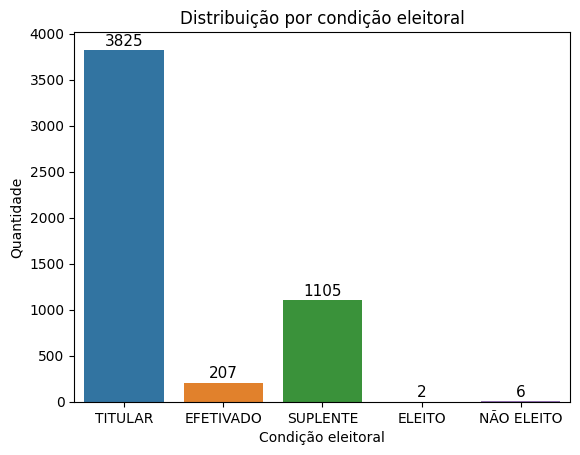

In [73]:
fig = sns.countplot(df[df['condicao_eleitoral'] != "SEM_INFORMACAO"], x='condicao_eleitoral',  palette='tab10')
fig.set(title="Distribuição por condição eleitoral", xlabel="Condição eleitoral", ylabel="Quantidade");

for c in fig.containers:
    fig.bar_label(c, fontsize=11, padding=1)

### Analisando a distribuição de deputados por quantidade de eleições

##### Para este gráfico o foco foram a quantidade de eleições que os deputados venceram, permitindo identificar a experiência eleitoral dos parlamentares. Observamos que a maioria dos deputados federais venceu apenas uma eleição, indicando uma grande renovação na Câmara dos Deputados. No entanto, há também um número significativo de deputados que venceram múltiplas eleições, o que pode refletir a consolidação de carreiras políticas e a construção de bases eleitorais sólidas ao longo do tempo. Essa análise ajuda a entender a dinâmica de reeleição e a estabilidade das carreiras políticas no cenário legislativo brasileiro, e com isso vendo que tinhamos extremos que venceram entre 11 e 9 vezes, assim surgindo a curiosidade para investigar quem eram esses deputados que venceram tantas eleições. Com isso, descobrimos que o deputado federal mais vezes eleito é o ex-presidente da Câmara dos Deputados, ``Henrique Eduardo Alves``, que venceu 11 eleições. Já o segundo deputado mais vezes eleito é o ex-deputado federal e ex-presidente da Câmara dos Deputados, ``Ulysses Guimarães``, que venceu 11 eleições e foi um dos maiores opositores da ditadura militar, tendo um fim trágico e suspeito em 1992 em um acidente de avião. Ambos os parlamentares tiveram uma longa trajetória política e desempenharam papéis significativos no cenário legislativo brasileiro.

C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\753055251.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.countplot(df, x='quantidade_eleicoes', palette='tab10')


C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\753055251.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.countplot(df, x='quantidade_eleicoes', palette='tab10')


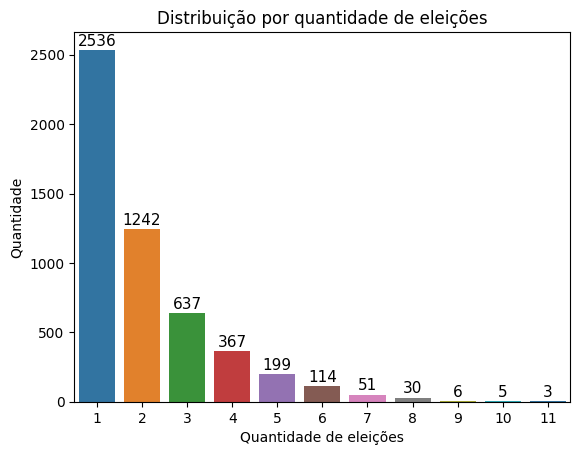

In [74]:
fig = sns.countplot(df, x='quantidade_eleicoes', palette='tab10')
fig.set(title="Distribuição por quantidade de eleições", xlabel="Quantidade de eleições", ylabel="Quantidade");

for c in fig.containers:
    fig.bar_label(c, fontsize=11, padding=1)

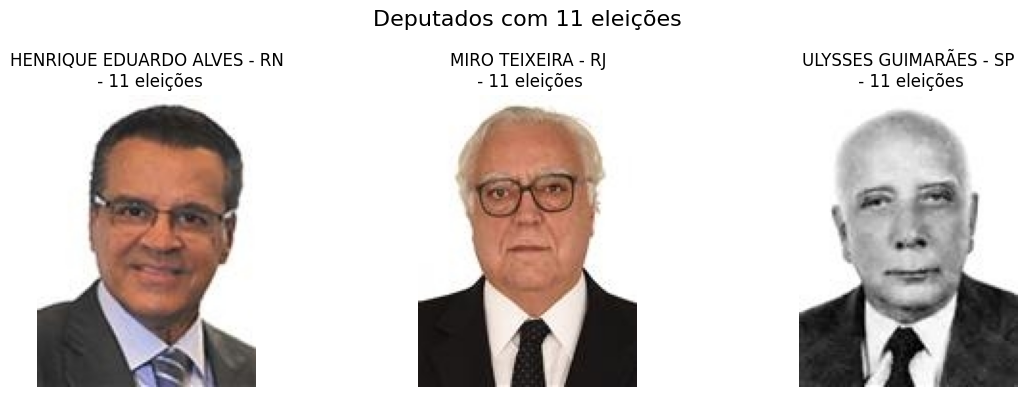

In [50]:
onze_eleicoes = df[df['quantidade_eleicoes'] == 11]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

for i, (_, row) in enumerate(onze_eleicoes.iterrows()):
    nome = row['nome_parlamentar']
    url = row['url_foto']
    estado = row['sigla_uf'].replace("[", "").replace("]", "").replace("'", "").split(",")[0].strip()
    quantidaed_eleicoes = row['quantidade_eleicoes']

    response = requests.get(url)
    img = Image.open(BytesIO(response.content))

    ax[i].imshow(img)
    ax[i].set_title(f"{nome} - {estado}\n - {quantidaed_eleicoes} eleições")
    ax[i].axis('off')

plt.suptitle("Deputados com 11 eleições", fontsize=16)
plt.tight_layout()
plt.show()

### Analisando a distribuição de deputados mais votados por quantidade de eleições do sexo feminino

##### Seguindo a lógica da análise anterior, neste gráfico focamos nas deputadas federais mais votadas, analisando a quantidade de eleições que venceram. Observamos que a maioria das deputadas federais mais votadas venceu apenas uma eleição, e possuem um número muito menor que o setor masculino, o que reflete a sub-representação histórica das mulheres na política brasileira. No entanto, também identificamos algumas deputadas que venceram múltiplas eleições, como destaque tivemos a deputada federal ``Luiza Erundina`` que é a primeira mulher a ser eleita como prefeita de São Paulo e primeira mulher nordestina a assumir o cargo de deputada federal onde venceu 7 eleições, sendo uma das figuras mais importantes da política brasileira, conhecida por sua atuação em defesa dos direitos humanos e das causas sociais. Essa análise evidencia a trajetória e a representatividade das mulheres na política, destacando as conquistas e os desafios enfrentados pelas deputadas federais ao longo de suas carreiras.

C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\412969704.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.countplot(df[df['sexo'] == "F"], x='quantidade_eleicoes', palette='tab10')


C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\412969704.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.countplot(df[df['sexo'] == "F"], x='quantidade_eleicoes', palette='tab10')


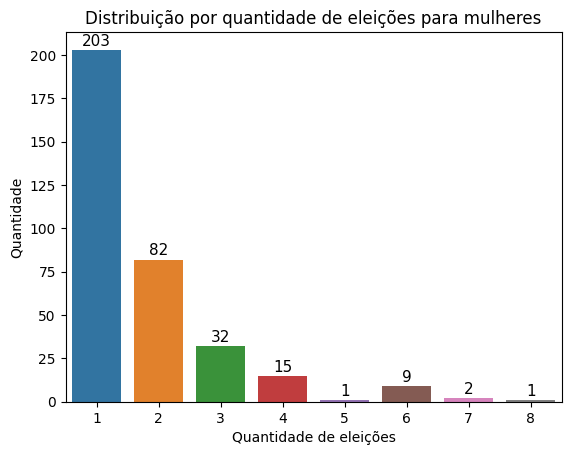

In [75]:
fig = sns.countplot(df[df['sexo'] == "F"], x='quantidade_eleicoes', palette='tab10')
fig.set(title="Distribuição por quantidade de eleições para mulheres", xlabel="Quantidade de eleições", ylabel="Quantidade");

for c in fig.containers:
    fig.bar_label(c, fontsize=11, padding=1)

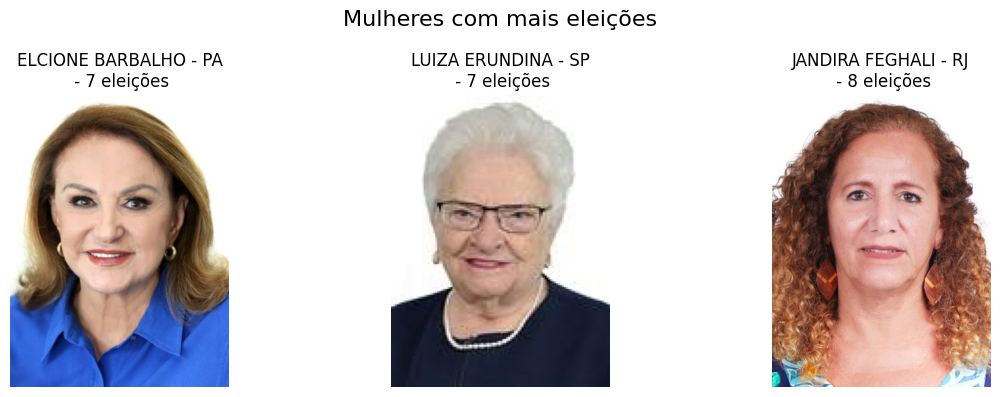

In [52]:
mulheres_eleicoes = df[(df['quantidade_eleicoes'] > 6) & (df['sexo'] == "F")]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

for i, (_, row) in enumerate(mulheres_eleicoes.iterrows()):
    nome = row['nome_parlamentar']
    url = row['url_foto']
    estado = row['sigla_uf'].replace("[", "").replace("]", "").replace("'", "").split(",")[0].strip()
    quantidaed_eleicoes = row['quantidade_eleicoes']
    

    response = requests.get(url)
    img = Image.open(BytesIO(response.content))

    ax[i].imshow(img)
    ax[i].set_title(f"{nome} - {estado}\n - {quantidaed_eleicoes} eleições")
    ax[i].axis('off')

plt.suptitle("Mulheres com mais eleições", fontsize=16)
plt.tight_layout()
plt.show()

### Boxplot da quantidade de eleições

##### Com o boxplot fica mais claro ainda que a grande massa se encontra entre os deputados que venceram entre uma e três eleições, com isso podemos perceber que a rotação de deputados é alta, o que pode indicar uma renovação constante na Câmara dos Deputados. Portanto, os outliers estão exatamente no range das deputadas que mais venceram e os deputados que mais venceram, entre sete e onze eleições, onde reforça a ideia de que com mais reeleições os deputados tendem a ter uma carreira sólida na legislatura brasileira, como vimos nos exemplos de `Ulysses Guimarães` e `Luiza Erundina` que fizeram coisas de extrema importância para a política brasileira, e que com isso, a reeleição pode ser um indicativo de influência e relevância dentro do cenário político nacional.

[Text(0.5, 1.0, 'Boxplot da quantidade de eleições'),
 Text(0.5, 0, 'Quantidade de eleições')]

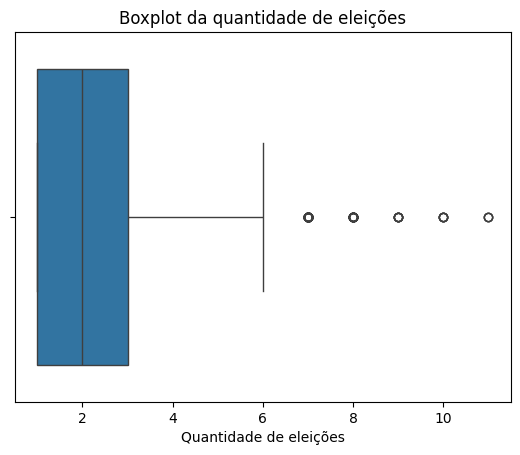

In [53]:
fig = sns.boxplot(df, x='quantidade_eleicoes')
fig.set(title="Boxplot da quantidade de eleições", xlabel="Quantidade de eleições")

### Relação entre colunas
Agora que ja realizamos uma análise geral dos dados, podemos analisar como esses dados se relacionam entre si.

##### No gráfico a seguir verificamos a relaçào entre `homens x mulheres` por estado onde fica mais claro ainda a discrepância entre os sexos, onde os homens possuem uma presença muito maior que as mulheres, com isso para ter uma noção melhor dos estados que mais elegem mulheres criamos um gráfico com o percentual das mulheres por estado, onde de primeiro instante conseguimos ver que os estados nordestinos tendem a eleger menos mulheres com destaque para Paraíba e Sergipe que somados possuem 7 mulheres eleitas na história, com exceção do Rio Grande do Norte que possui ``8.25%`` de mulheres eleitas todos os outros estados nordestinos possuem um percentual muito baixo. Já os estados do norte tendem a ter um percentual mais alto visto que possuem um total menor que os grandes estados, como São Paulo e Rio de Janeiro que são os estados com maior representatividade feminina porem o percentual é mais baixo por possuir uma grande massa de homens, o norte recebe destaque com o Amapá que possui ``22.95%`` de mulheres eleitas, que é o percentual mais alto entre os estados brasileiros. Logo esta análise evidencia a desigualdade de gênero na política brasileira, destacando a necessidade de políticas públicas e ações afirmativas para promover a participação feminina na esfera legislativa.

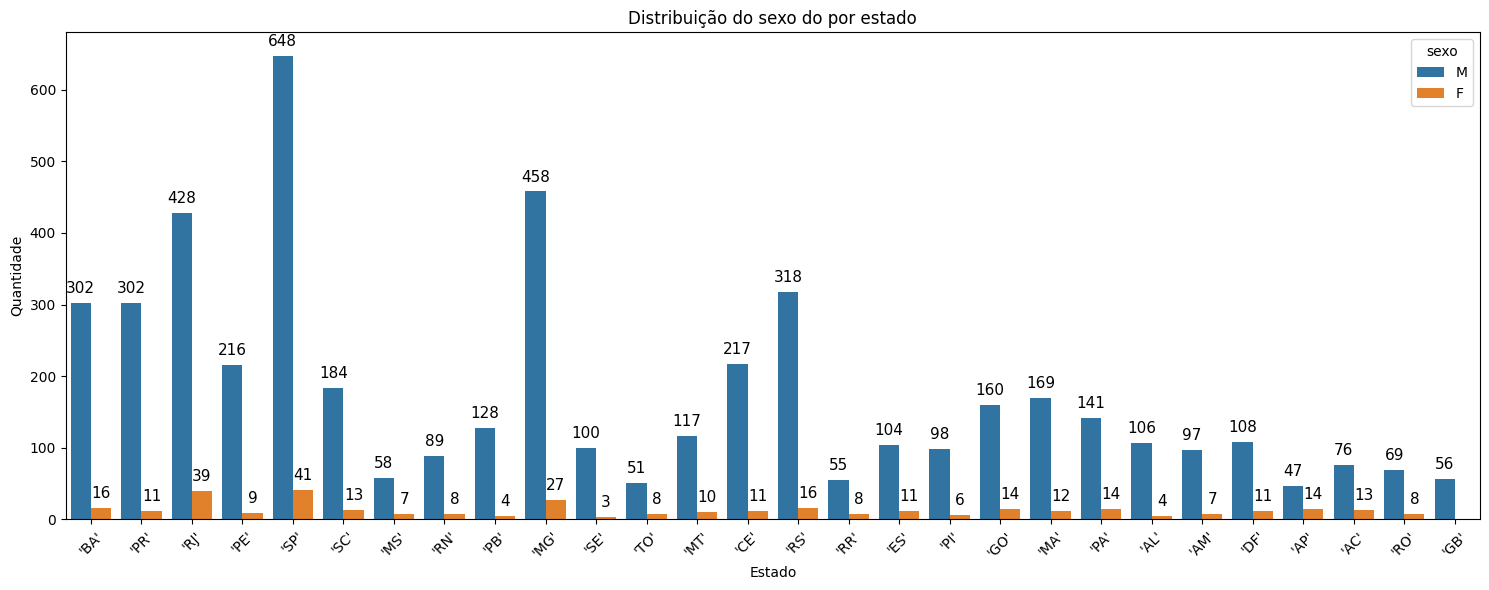

In [54]:
plt.figure(figsize=(15, 6))

aux_estado = df[["sexo", "sigla_uf"]].dropna().copy()

aux_estado["sigla_uf"] = (
    aux_estado["sigla_uf"]
    .astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace('"', "", regex=False)
    .str.split(",")
)

aux_estado = aux_estado.explode("sigla_uf")
aux_estado["sigla_uf"] = aux_estado["sigla_uf"].str.strip()
aux_estado = aux_estado[aux_estado["sigla_uf"] != ""]


fig = sns.countplot(data=aux_estado, x="sigla_uf", hue="sexo", palette='tab10')
fig.set(title="Distribuição do sexo do por estado", xlabel="Estado", ylabel="Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()

for c in fig.containers:
    fig.bar_label(c, fontsize=11, padding=5)

In [55]:
def percentual_mulheres(x):
    return (x=="F").sum() / len(x) * 100

C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\1726454156.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.barplot(data=aux_estado.head(26), x="sigla_uf", y="percentual_mulheres", palette="tab10")


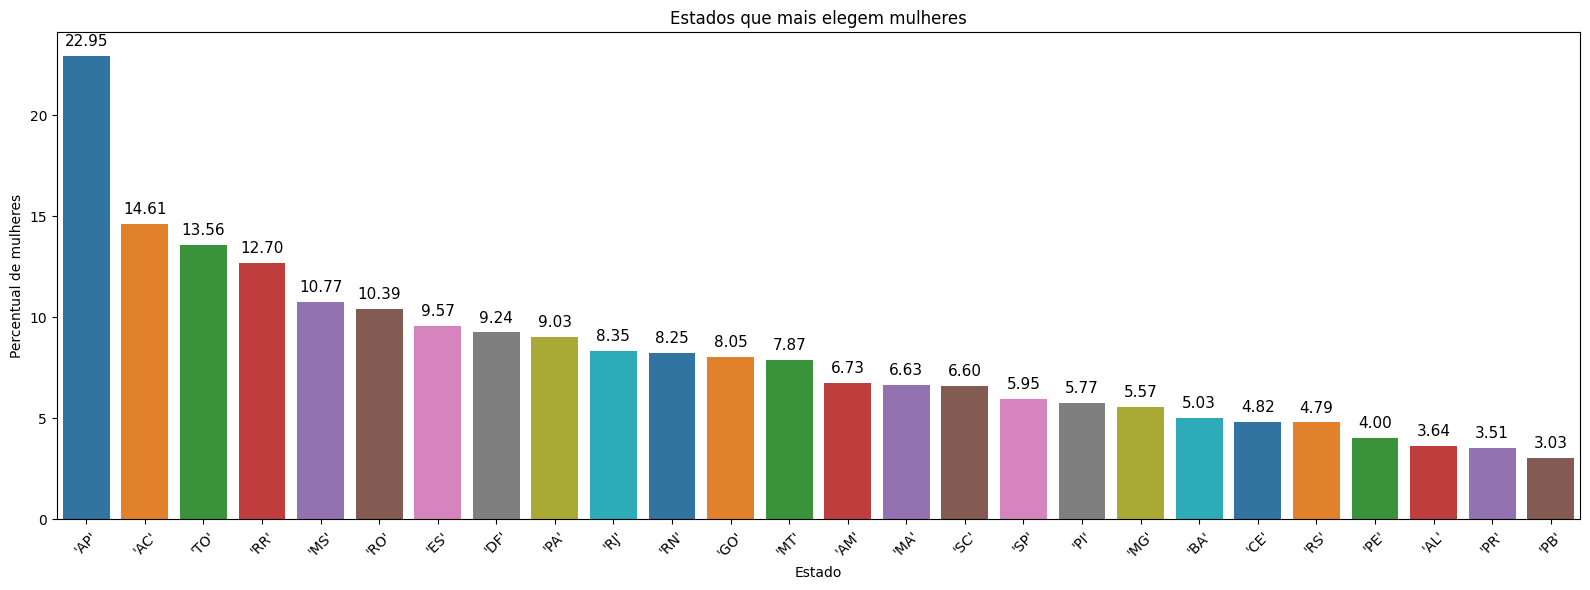

In [56]:
aux_estado = (
    aux_estado.groupby("sigla_uf")["sexo"]
    .apply(percentual_mulheres)
    .reset_index(name="percentual_mulheres")
    .sort_values(by="percentual_mulheres", ascending=False)
)

plt.figure(figsize=(16, 6))
fig = sns.barplot(data=aux_estado.head(26), x="sigla_uf", y="percentual_mulheres", palette="tab10")
fig.set(title="Estados que mais elegem mulheres", xlabel="Estado", ylabel="Percentual de mulheres")
plt.xticks(rotation=45)
plt.tight_layout()

for c in fig.containers:
    fig.bar_label(c, fontsize=11, padding=5, fmt='%.2f')

### Analisando a distribuição de deputados relacionados ao partido e sexo

##### Nesta analise temos alguns destaques princiais como o fato do partido PT ser o partido que mais elegeu mulheres, seguido pelo PMDB e PSDB, o que pode refletir uma maior abertura e incentivo à participação feminina nesses partidos. Já os partidos com menor representatividade feminina, com destaque para ARENA e UDN que somados possuem 2 mulheres eleitas, podem indicar uma falta de políticas internas para promover a inclusão das mulheres ou uma cultura partidária menos receptiva à diversidade de gênero. Essa análise ajuda a entender as dinâmicas de gênero dentro dos partidos políticos brasileiros, evidenciando quais legendas têm se destacado na promoção da participação feminina e quais ainda enfrentam desafios significativos nesse aspecto.

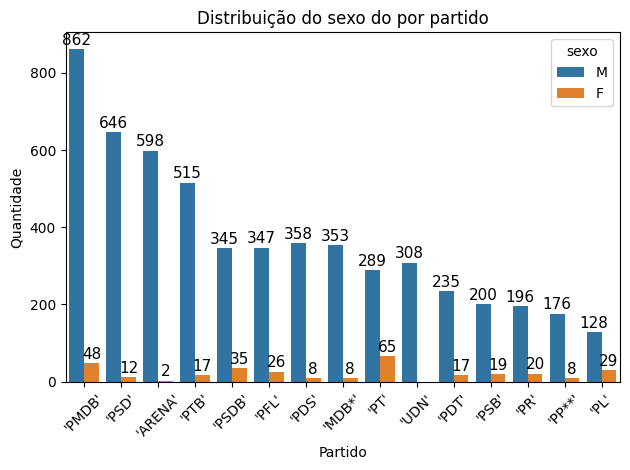

In [76]:
aux_partido = df[["sexo", "sigla_partido"]].dropna().copy()

aux_partido["sigla_partido"] = (
    aux_partido["sigla_partido"]
    .astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace('"', "", regex=False)
    .str.split(",")
)

aux_partido = aux_partido.explode("sigla_partido")
aux_partido["sigla_partido"] = aux_partido["sigla_partido"].str.strip()
aux_partido = aux_partido[aux_partido["sigla_partido"] != ""]

top15 = aux_partido["sigla_partido"].value_counts().head(15).index
aux_partido = aux_partido[aux_partido["sigla_partido"].isin(top15)]


fig = sns.countplot(data=aux_partido[aux_partido['sigla_partido'].isin(top15)], x="sigla_partido", hue="sexo", palette='tab10', order=top15)
fig.set(title="Distribuição do sexo do por partido", xlabel="Partido", ylabel="Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()

for c in fig.containers:
    fig.bar_label(c, fontsize=11, padding=1)

##### Analisando o percentual vemos que os principais partidos atuais PT e PL possuem um valor muito parecido, mesmo possuindo ideologias totalmente opostas, o que pode indicar que a ideologia do partido não é um fator determinante para a eleição de mulheres, e sim outros fatores como políticas internas de incentivo à participação feminina, cultura partidária e estratégias de campanha. Já os partidos com menor percentual de mulheres eleitas, como o ARENA e o UDN, podem refletir uma falta de foco ou prioridade na promoção da igualdade de gênero dentro dessas legendas. Essa análise evidencia a complexidade das dinâmicas de gênero na política brasileira, mostrando que a representatividade feminina pode ser influenciada por uma variedade de fatores além da ideologia partidária.

C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\3682301156.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.barplot(data=aux_partido.head(26), x="sigla_partido", y="percentual_mulheres", palette="tab10")


C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\3682301156.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.barplot(data=aux_partido.head(26), x="sigla_partido", y="percentual_mulheres", palette="tab10")


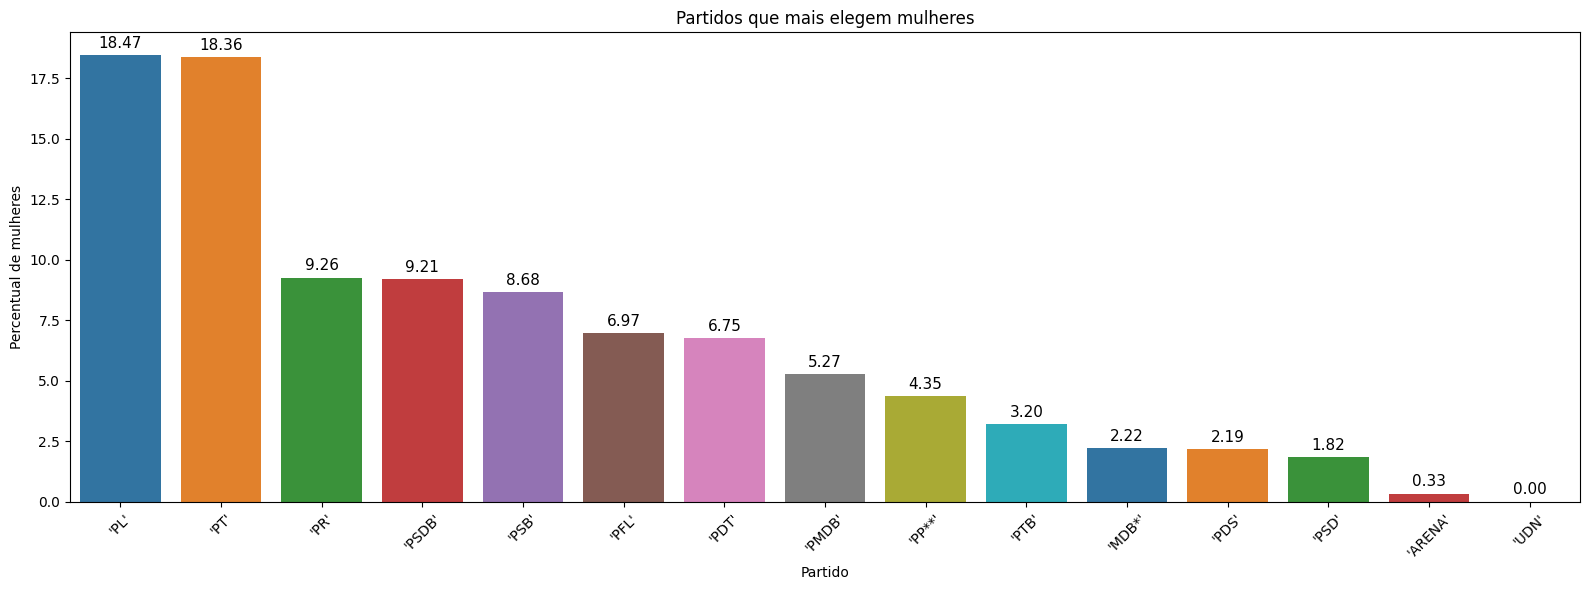

In [77]:
aux_partido = (
    aux_partido.groupby("sigla_partido")["sexo"]
    .apply(percentual_mulheres)
    .reset_index(name="percentual_mulheres")
    .sort_values(by="percentual_mulheres", ascending=False)
)

plt.figure(figsize=(16, 6))
fig = sns.barplot(data=aux_partido.head(26), x="sigla_partido", y="percentual_mulheres", palette="tab10")
fig.set(title="Partidos que mais elegem mulheres", xlabel="Partido", ylabel="Percentual de mulheres")
plt.xticks(rotation=45)
plt.tight_layout()

for c in fig.containers:
    fig.bar_label(c, fontsize=11, padding=3, fmt='%.2f')

### Analisando o boxplot da escolaridade pela quantidade de eleições

##### Com este boxplot fica claro que com base nos outliers, os deputados com ensino superior completo, doutorado ou PhD tendem a vencer mais eleições, o que pode indicar que a escolaridade é um fator importante para o sucesso eleitoral dos parlamentares. Já os deputados com ensino médio completo e ensino fundamental completo possuem uma distribuição mais concentrada em um número menor de eleições vencidas, o que pode refletir uma menor experiência ou influência política. Essa análise sugere que a educação formal pode desempenhar um papel significativo na trajetória política dos deputados federais, influenciando sua capacidade de se manterem eleitos ao longo do tempo.

C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\3593587384.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.boxplot(df, x='quantidade_eleicoes', y='escolaridade', palette='tab10')


[Text(0.5, 1.0, 'Boxplot da escolaridade por quantidade de eleições'),
 Text(0.5, 0, 'Quantidade de eleições'),
 Text(0, 0.5, 'Escolaridade')]

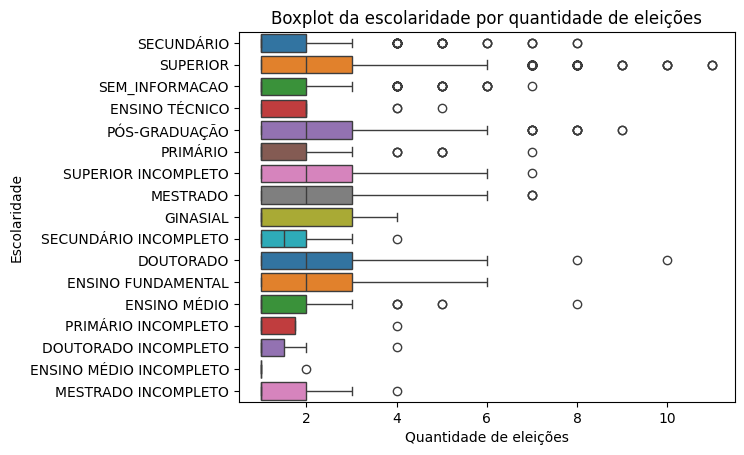

In [59]:
fig = sns.boxplot(df, x='quantidade_eleicoes', y='escolaridade', palette='tab10')
fig.set(title="Boxplot da escolaridade por quantidade de eleições", xlabel="Quantidade de eleições", ylabel="Escolaridade")

##### O mesmo padrão se repete para as mulheres, onde o destaque dos outliers fica entre ensino superior completo, mestrado e PhD, onde vemos novamente como a escolaridade influencia na longevidade das carreiras políticas.

C:\Users\arthxrzzz\AppData\Local\Temp\ipykernel_11448\2445229630.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.boxplot(df[df['sexo'] == "F"], x='quantidade_eleicoes', y='escolaridade', palette='tab10')


[Text(0.5, 1.0, 'Boxplot da escolaridade por quantidade de eleições - Mulheres'),
 Text(0.5, 0, 'Quantidade de eleições'),
 Text(0, 0.5, 'Escolaridade')]

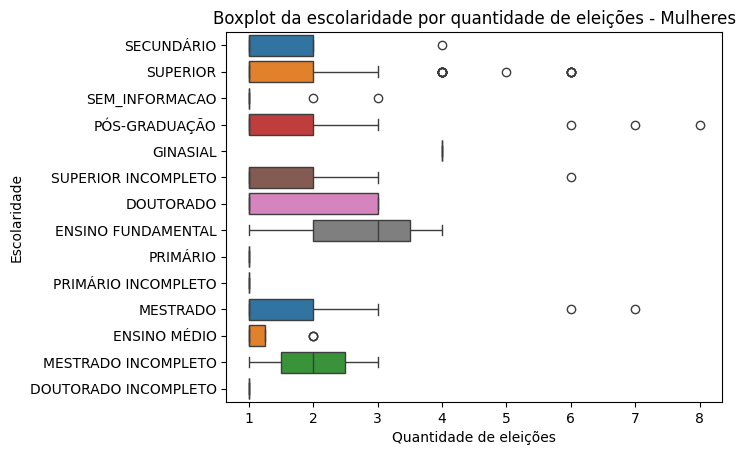

In [60]:
fig = sns.boxplot(df[df['sexo'] == "F"], x='quantidade_eleicoes', y='escolaridade', palette='tab10')
fig.set(title="Boxplot da escolaridade por quantidade de eleições - Mulheres", xlabel="Quantidade de eleições", ylabel="Escolaridade")

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   id                          5190 non-null   int64
 1   nome_parlamentar            5190 non-null   str  
 2   sigla_partido               5190 non-null   str  
 3   uri_partido                 5187 non-null   str  
 4   sigla_uf                    5190 non-null   str  
 5   id_legislatura              5190 non-null   str  
 6   url_foto                    5190 non-null   str  
 7   sexo                        5190 non-null   str  
 8   ultima_situacao             5190 non-null   str  
 9   condicao_eleitoral          5190 non-null   str  
 10  falecido                    5190 non-null   int64
 11  uf_nascimento               5190 non-null   str  
 12  escolaridade                5190 non-null   str  
 13  ano_nascimento              5155 non-null   Int64
 14  quantidade_eleicoes

## Conclusão

### Resultados

1. **Perfil Demográfico**: A Câmara dos Deputados é predominantemente masculina (cerca de 85% dos deputados), com uma distribuição etária concentrada entre 40 e 60 anos na última legislatura. A maioria possui ensino superior completo, refletindo um alto nível educacional entre os parlamentares.

2. **Carreiras Políticas**: Observamos uma alta rotatividade, com a maioria dos deputados tendo vencido apenas uma eleição. No entanto, há casos notáveis de longevidade política, como Henrique Eduardo Alves e Ulysses Guimarães, que venceram 11 eleições cada. Entre as mulheres, Luiza Erundina se destaca com 7 eleições.

3. **Desigualdade de Gênero**: As mulheres representam uma minoria significativa, com percentuais variando por estado e partido. Estados do Norte, como Amapá, e partidos como PT e PMDB mostram maior representatividade feminina, mas ainda há uma sub-representação geral.

4. **Correlações Identificadas**: Há uma correlação positiva entre nível educacional e longevidade política, com deputados mais escolarizados tendendo a vencer mais eleições. A ideologia partidária não parece ser o principal determinante para a eleição de mulheres.

5. **Distribuição Regional e Partidária**: Estados como São Paulo, Minas Gerais e Rio de Janeiro concentram mais deputados, enquanto partidos tradicionais como PMDB (MDB) e PSD dominam em termos de representação.

### Limitações

- Os dados analisados são históricos e podem não refletir mudanças recentes na composição da Câmara.
- Algumas colunas apresentavam valores nulos, tratados com preenchimento padrão, o que pode introduzir viés.
- A análise se limitou a variáveis disponíveis na API; dados adicionais (como votações específicas) poderiam enriquecer os insights.

### Contribuições e Impacto

Este estudo contribui para a transparência e compreensão da política brasileira, destacando desigualdades e padrões que podem informar políticas públicas, como cotas de gênero e incentivos à renovação parlamentar. A metodologia aplicada demonstra o potencial da ciência de dados para analisar instituições democráticas.

### Trabalhos Futuros

Sugere-se expandir a análise para incluir dados de votações, proposições legislativas e redes de relacionamento entre deputados. Além disso, comparações temporais e integração com dados socioeconômicos poderiam fornecer insights mais profundos sobre a influência dos parlamentares na sociedade brasileira.

Em suma, este projeto reforça a importância da análise de dados na promoção de uma democracia mais informada e equitativa.